# Error scheme experiments

In [1]:
import matplotlib.pyplot as plt 
import jax
import numpy as np 
import equinox as eqx
import os
import jax.numpy as jnp

In [2]:
from datasets import init_dataloaders
from solvers.runge_kutta import RK_solver_fixed, RK_tableaux
from forecasters import *
from networks import *
from utils import *

## 1. dt_num = 0 procedure

Loop decreasing dt to determine when $y_{dt/2}(T) - y_{dt}(T) \leq 10^{-12}$ ie when decreasing the time step does not change the integration scheme outcome: we reached the numerical limit of the scheme, dt_num=0

T=12, $dt_0$=2

Pb: in practice I don't observe this... The error decreases but then starts increasing when dt becomes very small: unstable. 

In [257]:
def F(y,t): # damped pendulum
    q,p = y[0], y[1]
    return jnp.array([p, -(2*np.pi/12)**2 * jnp.sin(q)-0.2*p])

def F_linear(y,t): # damped pendulum small angles 
    q,p = y[0], y[1]
    return jnp.array([p, -(2*np.pi/12)**2 * q-0.2*p])

12 12.0


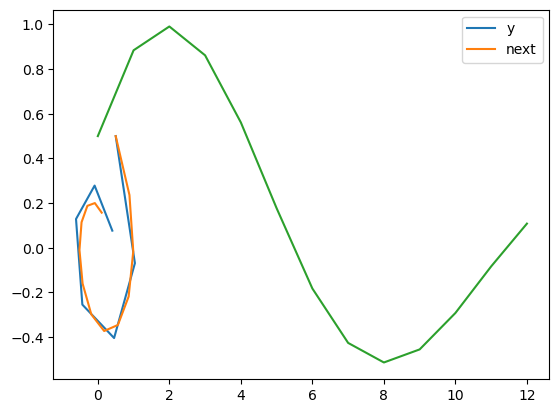

1.0 0.18867697
final_t True
0.5 0.042992897
final_t True
0.25 0.010820005
final_t True
0.125 0.00269307
final_t True
0.0625 0.00066819135
final_t True
0.03125 0.00016620383
final_t True
0.015625 4.120823e-05
final_t True
0.0078125 1.0413118e-05
final_t True
0.00390625 2.5844201e-06
final_t True
0.001953125 7.171184e-07
final_t True
0.0009765625 4.3027103e-07
final_t True
0.00048828125 1.3010576e-06
final_t True
0.000244140625 2.8917566e-06
final_t True
0.0001220703125 6.47828e-06
final_t True
6.103515625e-05 2.115965e-06
final_t True
3.0517578125e-05 2.055429e-06
final_t True
1.52587890625e-05 0.00011357758
final_t True
7.62939453125e-06 0.00029243808
final_t True
3.814697265625e-06 0.0007335581 0.00029243808


/Users/mayajanvier/.conda/envs/jax_env/lib/python3.10/site-packages/IPython/core/events.py:89: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)


<Figure size 640x480 with 0 Axes>

/Users/mayajanvier/.conda/envs/jax_env/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


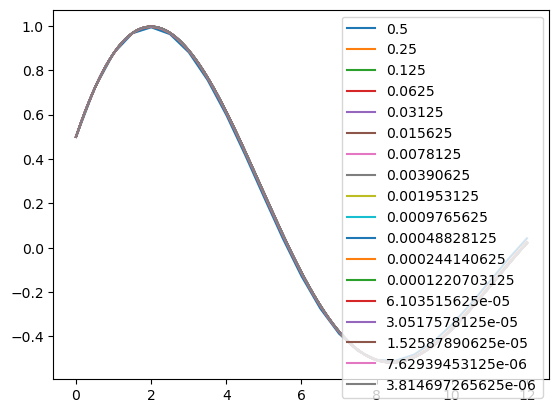

In [232]:
# RK2 
tableau = RK_tableaux["RK2"]
y0 = jnp.array([0.5, 0.5])
t0 = 0
t1 = 12
dt = 2
tol = 1e-8
dt_truth = 0.01
y_truth,_,_,_ = RK_solver_fixed(F,y0,dt_truth, int((t1 - t0) / dt_truth),RK_tableaux["RK4"])
y, t_eval,_,_= RK_solver_fixed(F,y0,dt, int((t1 - t0) / dt),tableau) #y(T)
plt.plot(y[0,:], y[1,:], label="y")
y = y[:,-1]
dt = dt/2
y_next, t_eval_next,_,_ = RK_solver_fixed(F,y0,dt,int((t1 - t0) / dt), tableau)
plt.plot(y_next[0,:], y_next[1,:], label="next")
plt.plot(y_next[0,:])
print(t_eval[-1], t_eval_next[-1])
plt.legend()
plt.show()
plt.figure()
y_next = y_next[:,-1]

min_diff = np.abs(y-y_next).mean()
dt_list = [dt]
error_list = []
error_RK4_list = []
# while np.abs(y-y_next).mean() >= tol:
#     if np.abs(y-y_next).mean() <= min_diff:
plt.figure()
for k in range(18):
    min_diff = np.abs(y-y_next).mean()
    print(dt, np.abs(y-y_next).mean())
    dt = dt/2
    dt_list.append(dt)
    error_list.append(min_diff)
    error_RK4_list.append(np.abs(y_truth[:,-1]-y_next).mean())
    y = y_next
    t_eval = t_eval_next
    y_next, t_eval_next,_,_ = RK_solver_fixed(F,y0,dt,int((t1 - t0) / dt), tableau)
    plt.plot(t_eval_next, y_next[0,:], label=f"{dt}")
    print("final_t", t_eval[-1]==t_eval_next[-1])
    y_next = y_next[:,-1]
print(dt, np.abs(y-y_next).mean(), min_diff)
plt.legend()

Text(0.5, 1.0, 'dt_num=0 procedure for RK2, $y_0$=[0.5,0.5]')

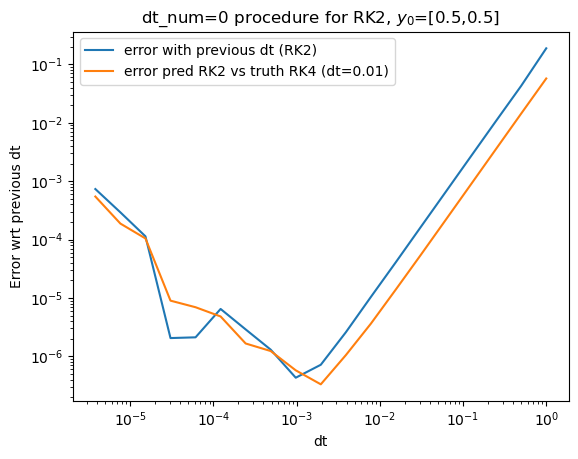

In [235]:
plt.plot(dt_list, error_list+ [np.abs(y-y_next).mean()], label="error with previous dt (RK2)")
plt.plot(dt_list, error_RK4_list + [np.abs(y_truth[:,-1]-y_next).mean()], label="error pred RK2 vs truth RK4 (dt=0.01)")
plt.legend()
plt.yscale("log")
plt.xscale("log")
plt.xlabel("dt")
plt.ylabel("Error wrt previous dt")
plt.title(r"dt_num=0 procedure for RK2, $y_0$=[0.5,0.5]")

Investigation of dt < dt_lim = 1e-3

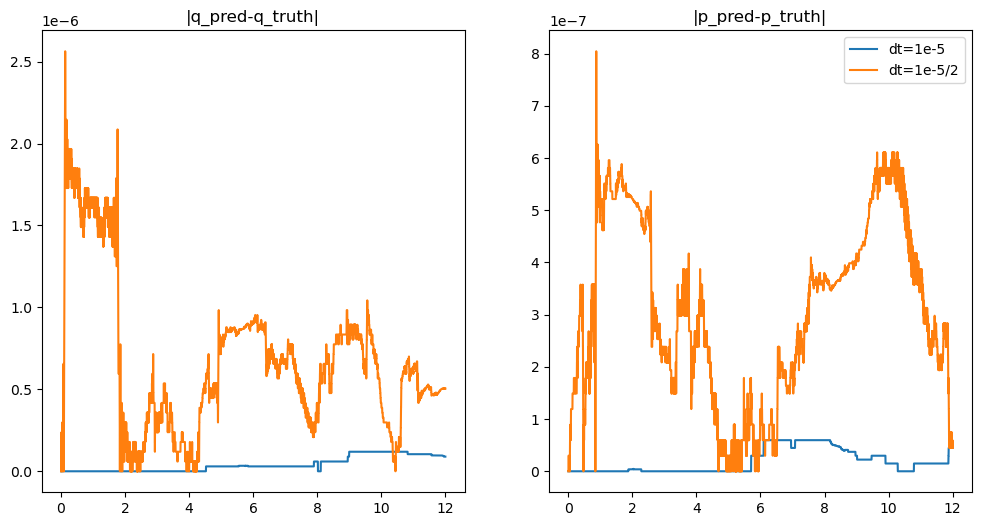

In [237]:
dt_truth = 1e-03
y_truth,t_eval_truth,_,_ = RK_solver_fixed(F,y0,dt_truth, int((t1 - t0) / dt_truth),RK_tableaux["RK4"])
#plt.plot(t_eval_truth, y_truth[0,:], label="truth")
y_next, t_eval_next,_,_ = RK_solver_fixed(F,y0,dt_truth,int((t1 - t0) / dt_truth), tableau)
y_next2, t_eval_next2,_,_ = RK_solver_fixed(F,y0,dt_truth/2,int(2*(t1 - t0) / dt_truth), tableau)
#plt.plot(t_eval_next, y_next[0,:], label="RK2")
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].set_title("|q_pred-q_truth|")
ax[1].set_title("|p_pred-p_truth|")
ax[0].plot(t_eval_next, np.abs(y_next[0,:]-y_truth[0,:]), label="dt=1e-3")
ax[1].plot(t_eval_truth, np.abs(y_next[1,:]-y_truth[1,:]), label="dt=1e-3")
ax[0].plot(t_eval_next, np.abs(y_next2[0,::2]-y_truth[0,:]), label="dt=1e-3/2")
ax[1].plot(t_eval_truth, np.abs(y_next2[1,::2]-y_truth[1,:]), label="dt=1e-3/2")
plt.legend()

[-0.1+0.51396077j -0.1-0.51396077j]
0.001 False
0.001 False
0.0001 False
0.0001 False
1e-05 False
1e-05 False
1e-06 False
1e-06 False
1e-07 False
1e-07 False


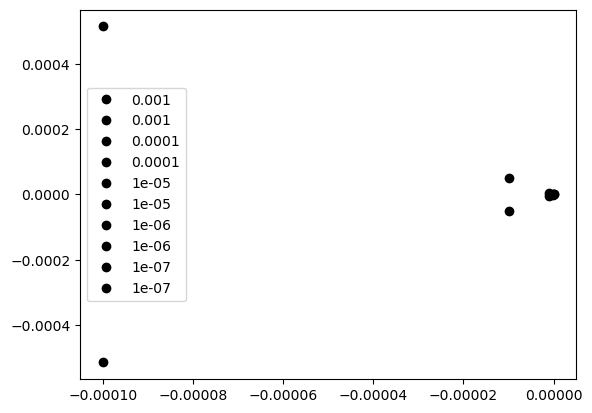

In [11]:
# stability analysis for F_linear
omega0_square = (2*jnp.pi/12)**2
A= np.array([[0,1],
             [-omega0_square, -0.2]])
# valeur propres
vp = np.linalg.eigvals(A)
re = -0.1
print(vp)
for dt in [1e-3,1e-4,1e-5, 1e-6,1e-7]:
    for v in vp:
        plt.plot(v.real*dt, v.imag*dt, 'ko', label=f"{dt}")
        print(dt, v.real*dt>0)

plt.legend()
plt.show()

Text(0, 0.5, 'Error wrt previous dt')

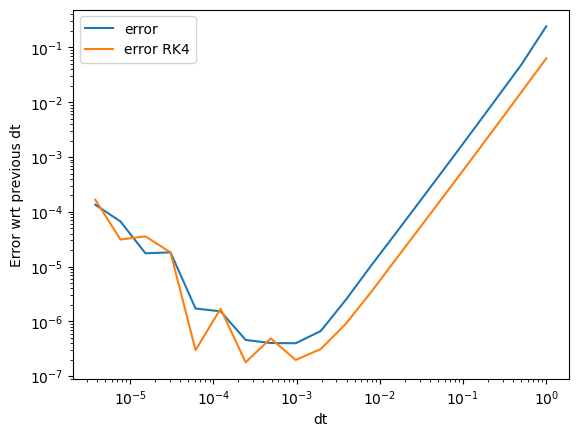

In [ ]:
plt.plot(dt_list, error_list+ [np.abs(y-y_next).mean()], label="error")
plt.plot(dt_list, error_RK4_list + [np.abs(y_truth[:,-1]-y_next).mean()], label="error RK4")
plt.legend()
plt.yscale("log")
plt.xscale("log")
plt.xlabel("dt")
plt.ylabel("Error wrt previous dt")

In [238]:
# same analysis for RK4
tableau = RK_tableaux["RK4"]
y0 = jnp.array([2, -1.5])
t0 = 0
t1 = 12
dt = 2
tol = 1e-8
y, _,_,_= RK_solver_fixed(F,y0,dt, int((t1 - t0) / dt),tableau) #y(T)
y = y[:,-1]
dt = dt/2
y_next, _,_,_ = RK_solver_fixed(F,y0,dt,int((t1 - t0) / dt), tableau)
y_next = y_next[:,-1]
min_diff = np.abs(y-y_next).mean()
dt_list = [dt]
error_list = []
# while np.abs(y-y_next).mean() >= tol:
#     if np.abs(y-y_next).mean() <= min_diff:
for k in range(18):
    min_diff = np.abs(y-y_next).mean()
    print(dt, np.abs(y-y_next).mean())
    dt = dt/2
    dt_list.append(dt)
    error_list.append(min_diff)
    y = y_next
    y_next, _,_,_ = RK_solver_fixed(F,y0,dt,int((t1 - t0) / dt), tableau)
    y_next = y_next[:,-1]

print(dt, np.abs(y-y_next).mean(), min_diff)
opt_dt = dt*2

1.0 0.006159857
0.5 0.0027614087
0.25 0.000161618
0.125 2.168119e-05
0.0625 1.9669533e-06
0.03125 4.529953e-06
0.015625 4.4703484e-06
0.0078125 1.0088086e-05
0.00390625 2.194941e-05
0.001953125 2.5764108e-05
0.0009765625 1.5795231e-06
0.00048828125 1.9401312e-05
0.000244140625 3.567338e-05
0.0001220703125 0.00014865398
6.103515625e-05 0.00020572543
3.0517578125e-05 0.00010621548
1.52587890625e-05 0.0010145009
7.62939453125e-06 0.0067703426
3.814697265625e-06 0.0017608702 0.0067703426


Text(0, 0.5, 'Error wrt previous dt')

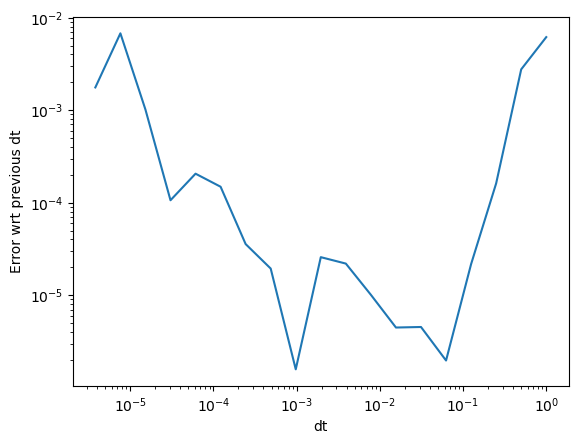

In [239]:
plt.plot(dt_list, error_list+ [np.abs(y-y_next).mean()])
plt.yscale("log")
plt.xscale("log")
plt.xlabel("dt")
plt.ylabel("Error wrt previous dt")

Encore moins stable avec RK4... et même dt=0 numerique, bizarre 

dt_num=0.05 -> 400 steps 

## 2. Inference, impact of dt

We want to see the order of the error when we change the order of the scheme. 
T=12, $dt_0$=0.05, $y_0$=[0.5,0.5]
dt_test=[2,4,8,16.32,64]*$dt_0$
We evaluate the absolute error on the trajectory for the same number of points for all (ie the ones with the biggest dt)

In [5]:
def F(y,t): # damped pendulum
    q,p = y[0], y[1]
    return jnp.array([p, -(2*np.pi/12)**2 * jnp.sin(q)-0.2*p])

In [7]:
# error on trajectory, without training
dt =  0.05
y0 = jnp.array([0.5, 0.5])
t0 = 0
t1 = 12
dt_list = [dt]
errors = []
y, _,_,_= RK_solver_fixed(F,y0,dt, int((t1 - t0) / dt),RK_tableaux["RK4"]) #y(T)
y2, _,_,_ = RK_solver_fixed(F,y0,dt, int((t1 - t0) / dt),RK_tableaux["RK2"]) #y(T)
errors.append(np.mean(np.abs(y[:,::64] - y2[:,::64])))
for k in [2,8,16,32, 64]:
    y3, _,_,_ = RK_solver_fixed(F,y0,dt*k, int((t1 - t0) / (dt*k)),RK_tableaux["RK2"]) #y(T)
    error_final = np.mean(np.abs(y[:,::64] - y3[:,::int(64/k)]))
    errors.append(error_final)
    #plt.scatter(dt*k,np.mean(np.abs(y[:,::16] - y3[:,::int(16/k)])), label=f"{k}")
    dt_list.append(dt*k)



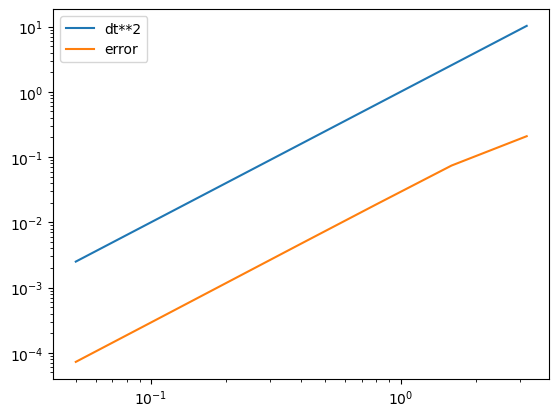

In [8]:
plt.plot(dt_list, np.array(dt_list)**2, label="dt**2")
plt.plot(dt_list, np.array(errors), label="error")
plt.yscale("log")
plt.xscale("log")
plt.legend()

Without any training, the error of trajectory is of order 2 (RK2).

Now we want to see if the parameters fitted with different dt, using RK2, have the same order of error.
Q: trajectories trained on all points or same points as max dt ? 
- trained on all points available (`error_scheme`)
- trained on same points as 16 (`error_scheme2`): dt=[2,8,16] * 0.05

In [240]:
# error_scheme
dict_paths =[
    "/Users/mayajanvier/jax-phynity/data/error_scheme/complete_physics_2_3tfct1zi/model_1.425e-07.json", 
    "/Users/mayajanvier/jax-phynity/data/error_scheme/complete_physics_3_3tfct1zi/model_5.455e-06.json",
    "/Users/mayajanvier/jax-phynity/data/error_scheme/complete_physics_4_3tfct1zi/model_3.518e-05.json",
    "/Users/mayajanvier/jax-phynity/data/error_scheme/complete_physics_5_3tfct1zi/model_8.506e-05.json",
    "/Users/mayajanvier/jax-phynity/data/error_scheme/complete_physics_6_3tfct1zi/model_5.444e-04.json",
]

# error_scheme2
dict_paths2 =[
    "/Users/mayajanvier/jax-phynity/data/error_scheme2/complete_physics_1_ms726d1v/model_1.401e-07.json",
    "/Users/mayajanvier/jax-phynity/data/error_scheme2/complete_physics_2_ms726d1v/model_3.491e-05.json",
    "/Users/mayajanvier/jax-phynity/data/error_scheme2/complete_physics_3_ms726d1v/model_5.444e-04.json",
]

In [280]:
loss_val = [1.425e-07, 5.455e-06, 3.518e-05, 8.506e-05, 5.444e-04]
loss_val2 = [1.401e-07, 3.491e-05, 5.444e-04]

In [241]:
# get omega, alpha 
omegas = []
alphas = []
for path in dict_paths:
    with open(path[:-21]+"/omega_alpha.json", "r") as f:
        data = json.load(f)
    print(data["omega"], data["alpha"])
    omegas.append(data["omega"])
    alphas.append(data["alpha"])

omegas2, alphas2 = [], []
for path in dict_paths2:
    with open(path[:-21]+"/omega_alpha.json", "r") as f:
        data = json.load(f)
    print(data["omega"], data["alpha"])
    omegas2.append(data["omega"])
    alphas2.append(data["alpha"])

0.27411317825317383 0.1999133825302124
0.27389439940452576 0.1995130479335785
0.2733769118785858 0.1989569514989853
0.2729674279689789 0.1985151171684265
0.2707677185535431 0.19758717715740204
0.274113267660141 0.19991332292556763
0.2733877897262573 0.19894836843013763
0.2707677185535431 0.19758717715740204


### 1. Error scheme trained on all points (`error_scheme`)
We train for different dt using RK2 (GT=RK4, dt=0.05), we evaluate on another one the same for all (dt_inf).

In [251]:
dt_truth = 0.05
dt_list = np.array([2,5,8,10,16])*dt_truth
dt_inf = 0.2 
print(dt_list, dt_inf)

[0.1  0.25 0.4  0.5  0.8 ] 0.2


#### Errors on parameters

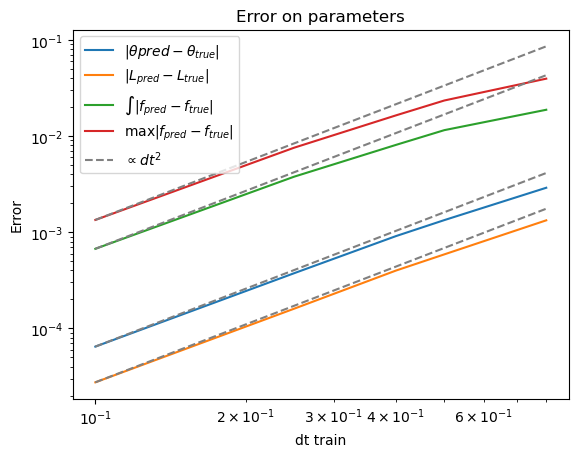

In [258]:
true_param = np.array([(2*np.pi/12)**2, 0.2])
L = np.sqrt(1+ true_param[0]**2 + true_param[1]**2)
q = np.linspace(-15, 15, 30)
p = np.linspace(-15, 15, 30)
Q, P = np.meshgrid(q, p) # points to evaluate error over domain
param_errors = []
L_errors = []
f_mean_errors = []
f_max_errors_ = [] 

for omega, alpha in zip(omegas,alphas):
    param_error = np.abs(np.array([omega,alpha])-true_param).mean()
    L_error = np.abs(np.sqrt(1+ omega**2 + alpha**2)-L)
    param_errors.append(param_error)
    L_errors.append(L_error)

    def F_error(y,t): 
        q,p = y[0], y[1]
        pred = jnp.array([p, -omega * jnp.sin(q)-alpha*p])
        true = jnp.array([p, -(2*np.pi/12)**2 * jnp.sin(q)-0.2*p])
        return np.linalg.norm(pred-true)
    
    # integrate over all y0
    m_error = []
    for y0 in zip(Q.ravel(), P.ravel()):
        y0 = np.array(y0)
        m_error.append(F_error(y0,0))
    f_mean_errors.append(np.array(m_error).mean())
    f_max_errors_.append(np.array(m_error).max())

plt.plot(dt_list, param_errors, label=r"$|\theta{pred} - \theta_{true}|$")
plt.plot(dt_list, L_errors, label=r"$|L_{pred} - L_{true}|$")
plt.plot(dt_list, f_mean_errors, label=r"$\int |f_{pred} - f_{true}|$")
plt.plot(dt_list, f_max_errors_, label=r"$\max |f_{pred} - f_{true}|$")
plt.plot(dt_list, (param_errors[0]/dt_list[0]**2)*dt_list**2, label=r"$\propto dt^2$", linestyle="--", color="grey")
plt.plot(dt_list, (L_errors[0]/dt_list[0]**2)*dt_list**2, linestyle="--", color="grey")
plt.plot(dt_list, (f_mean_errors[0]/dt_list[0]**2)*dt_list**2, linestyle="--", color="grey")
plt.plot(dt_list, (f_max_errors_[0]/dt_list[0]**2)*dt_list**2, linestyle="--", color="grey")
plt.yscale("log")
plt.xscale("log")
plt.xlabel("dt train")
plt.ylabel("Error")
plt.title("Error on parameters")
plt.legend()

#### Error on trajectory

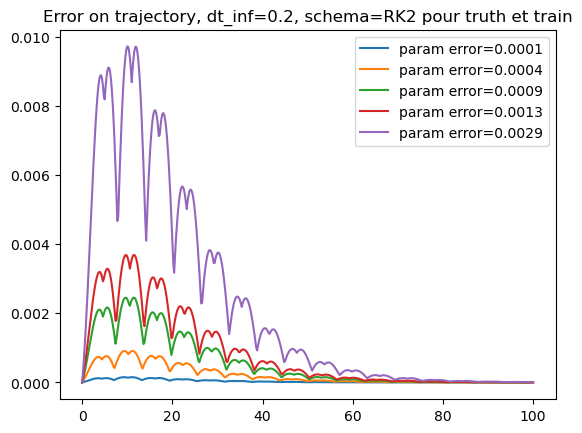

In [268]:
# error on trajectory, with training (ie fitting of theta)
### influence of dt_train (ie theta)
true_param = np.array([(2*np.pi/12)**2, 0.2])
max_errors = []
mean_errors = []
y0 = np.array([0.5,0.5])
dt_inf = 0.2 
t1 =100
dt_truth = 0.05
#y_true, _,_,_ = RK_solver_fixed(F,y0,dt_truth, int((t1-t0)/dt_truth),RK_tableaux["RK4"])
i = 0
for omega, alpha in zip(omegas,alphas):
    def F_theta(y,t): # pour dt=0.1
        q,p = y[0], y[1]
        return jnp.array([p, -omega * jnp.sin(q)-alpha*p])
    y_true,_,_,_ = RK_solver_fixed(F,y0,dt_inf, int((t1 - t0) / dt_inf),RK_tableaux["RK2"]) #y(T)
    y_pred,_,_,_ = RK_solver_fixed(F_theta,y0,dt_inf, int((t1 - t0) / dt_inf),RK_tableaux["RK2"]) #y(T)
    times = np.arange(t0,t1+dt_inf,dt_inf)
    plt.plot(times, np.abs(y_true-y_pred).mean(axis=0), label=f"param error={round(param_errors[i],4)}")
    max_errors.append( np.abs(y_true-y_pred).mean(axis=0).max())
    mean_errors.append( np.abs(y_true-y_pred).mean(axis=0).mean())
    i+=1
plt.legend()
plt.title("Error on trajectory, dt_inf=0.2, schema=RK2 pour truth et train")
plt.show()


Text(0.5, 1.0, 'L1 error on one trajectory, $y_0$=[0.5,0.5]')

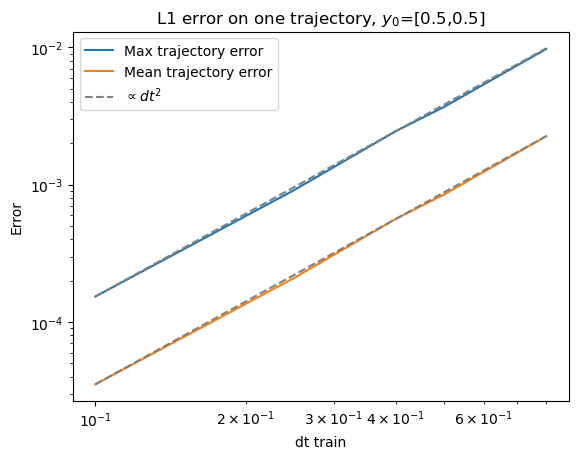

In [269]:
plt.plot(dt_list, max_errors, label="Max trajectory error")
plt.plot(dt_list, mean_errors, label="Mean trajectory error")
plt.plot(dt_list, (max_errors[0]/dt_list[0]**2)*dt_list**2, label=r"$\propto dt^2$", linestyle="--", color="grey")
plt.plot(dt_list, (mean_errors[0]/dt_list[0]**2)*dt_list**2, linestyle="--", color="grey")
plt.yscale("log")
plt.xscale("log")
plt.xlabel("dt train")
plt.legend()
plt.ylabel("Error")
plt.title(r"L1 error on one trajectory, $y_0$=[0.5,0.5]")

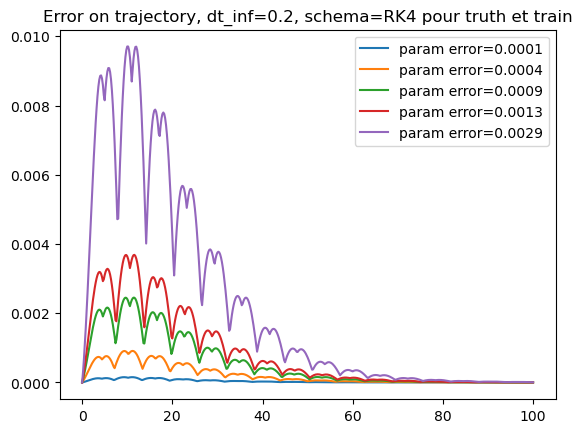

In [270]:
# error on trajectory, with training (ie fitting of theta)
### influence of dt_train (ie theta)
true_param = np.array([(2*np.pi/12)**2, 0.2])
max_errors = []
mean_errors = []
y0 = np.array([0.5,0.5])
dt_inf = 0.2 
t1 =100
dt_truth = 0.05
#y_true, _,_,_ = RK_solver_fixed(F,y0,dt_truth, int((t1-t0)/dt_truth),RK_tableaux["RK4"])
i = 0
for omega, alpha in zip(omegas,alphas):
    def F_theta(y,t): # pour dt=0.1
        q,p = y[0], y[1]
        return jnp.array([p, -omega * jnp.sin(q)-alpha*p])
    y_true,_,_,_ = RK_solver_fixed(F,y0,dt_inf, int((t1 - t0) / dt_inf),RK_tableaux["RK4"]) #y(T)
    y_pred,_,_,_ = RK_solver_fixed(F_theta,y0,dt_inf, int((t1 - t0) / dt_inf),RK_tableaux["RK4"]) #y(T)
    times = np.arange(t0,t1+dt_inf,dt_inf)
    plt.plot(times, np.abs(y_true-y_pred).mean(axis=0), label=f"param error={round(param_errors[i],4)}")
    max_errors.append( np.abs(y_true-y_pred).mean(axis=0).max())
    mean_errors.append( np.abs(y_true-y_pred).mean(axis=0).mean())
    i+=1
plt.legend()
plt.title("Error on trajectory, dt_inf=0.2, schema=RK4 pour truth et train")
plt.show()


Text(0.5, 1.0, 'L1 error on one trajectory, $y_0$=[0.5,0.5], RK4')

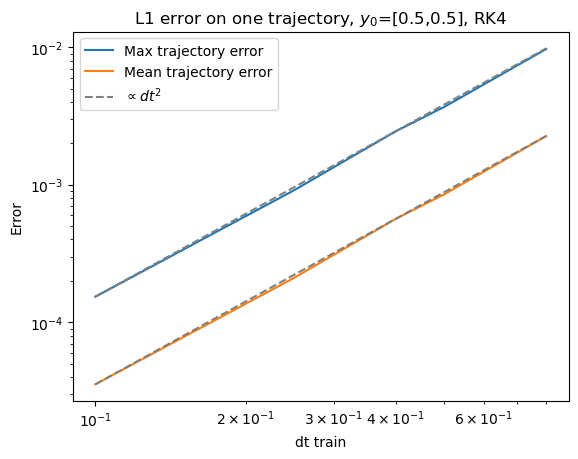

In [271]:
plt.plot(dt_list, max_errors, label="Max trajectory error")
plt.plot(dt_list, mean_errors, label="Mean trajectory error")
plt.plot(dt_list, (max_errors[0]/dt_list[0]**2)*dt_list**2, label=r"$\propto dt^2$", linestyle="--", color="grey")
plt.plot(dt_list, (mean_errors[0]/dt_list[0]**2)*dt_list**2, linestyle="--", color="grey")
plt.yscale("log")
plt.xscale("log")
plt.xlabel("dt train")
plt.legend()
plt.ylabel("Error")
plt.title(r"L1 error on one trajectory, $y_0$=[0.5,0.5], RK4")

In [287]:
dt_factors = (dt_list/dt_truth).astype(int)
dt_factors

array([ 2,  5,  8, 10, 16])

GT: RK4, dt=0.05

pred: RK2, dt de l'entrainement

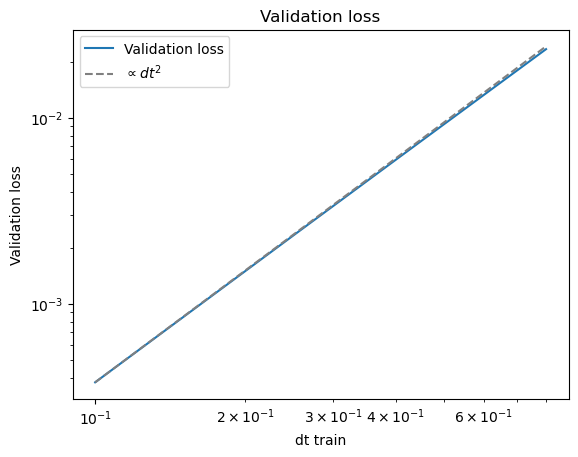

In [282]:
# loss on validation set
loss_val = np.array(loss_val) # loss val is MSE
loss_l1_val = np.sqrt(loss_val)
plt.plot(dt_list, loss_l1_val, label="Validation loss")
plt.plot(dt_list, (loss_l1_val[0]/dt_list[0]**2)*dt_list**2, label=r"$\propto dt^2$", linestyle="--", color="grey")
plt.legend()
plt.yscale("log")
plt.xscale("log")
plt.xlabel("dt train")
plt.ylabel("Validation loss")
plt.title("Validation loss")
plt.show()

(2, 1001) (2, 1001)
(2, 401) (2, 401)
(2, 251) (2, 251)
(2, 201) (2, 201)
(2, 126) (2, 127)


TypeError: sub got incompatible shapes for broadcasting: (2, 126), (2, 127).

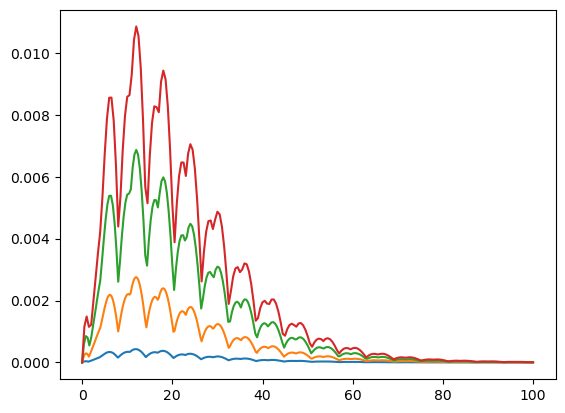

In [291]:
# error on trajectory, with training (ie fitting of theta)
### influence of dt_train (ie theta)
true_param = np.array([(2*np.pi/12)**2, 0.2])
max_errors = []
mean_errors = []
y0 = np.array([0.5,0.5])
dt_inf = 0.2 
t1 =100
dt_truth = 0.05

#y_true, _,_,_ = RK_solver_fixed(F,y0,dt_truth, int((t1-t0)/dt_truth),RK_tableaux["RK4"])
i = 0
for omega, alpha in zip(omegas,alphas):
    def F_theta(y,t): # pour dt=0.1
        q,p = y[0], y[1]
        return jnp.array([p, -omega * jnp.sin(q)-alpha*p])
    dt = dt_list[i]
    y_true,_,_,_ = RK_solver_fixed(F,y0,dt_truth, int((t1 - t0) / dt_truth),RK_tableaux["RK4"]) #y(T)
    y_pred,_,_,_ = RK_solver_fixed(F_theta,y0,dt, int((t1 - t0) / dt),RK_tableaux["RK2"]) #y(T)
    times = np.arange(t0,t1+dt,dt)
    print (y_true[:,::dt_factors[i]].shape, y_pred.shape)
    plt.plot(times, np.abs(y_true[:,::dt_factors[i]]-y_pred).mean(axis=0), label=f"param error={round(param_errors[i],4)}")
    max_errors.append( np.abs(y_true[:,::dt_factors[i]]-y_pred).mean(axis=0).max())
    mean_errors.append( np.abs(y_true[:,::dt_factors[i]]-y_pred).mean(axis=0).mean())
    i+=1
plt.legend()
plt.title("Error on trajectory, dt_inf=0.2, schema=RK4 pour truth, RK2 pour train")
plt.show()


Text(0.5, 1.0, 'L1 error on one trajectory, $y_0$=[0.5,0.5], RK4 GT RK2 pred')

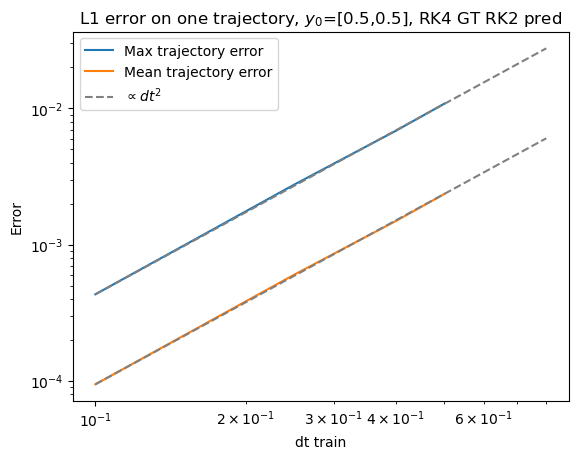

In [293]:
plt.plot(dt_list[:-1], max_errors, label="Max trajectory error")
plt.plot(dt_list[:-1], mean_errors, label="Mean trajectory error")
plt.plot(dt_list, (max_errors[0]/dt_list[0]**2)*dt_list**2, label=r"$\propto dt^2$", linestyle="--", color="grey")
plt.plot(dt_list, (mean_errors[0]/dt_list[0]**2)*dt_list**2, linestyle="--", color="grey")
plt.yscale("log")
plt.xscale("log")
plt.xlabel("dt train")
plt.legend()
plt.ylabel("Error")
plt.title(r"L1 error on one trajectory, $y_0$=[0.5,0.5], RK4 GT RK2 pred")

Text(0.5, 1.0, 'L1 error on one trajectory, $y_0$=[0.5,0.5], RK4 truth RK2 pred')

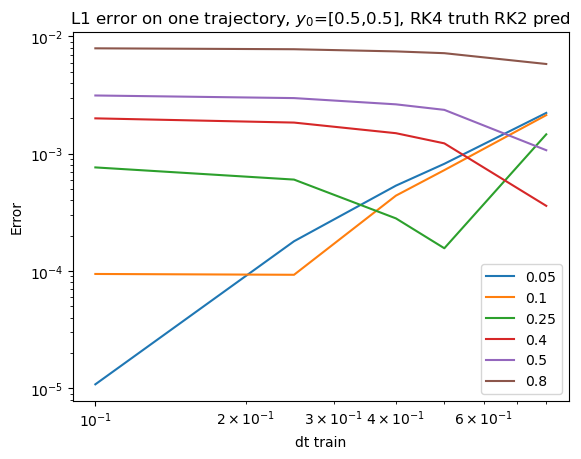

In [314]:
# error on trajectory, with training (ie fitting of theta)
### influence of dt_train (ie theta)

for dt_inf in np.concatenate([np.array([0.05]), dt_list]):
    true_param = np.array([(2*np.pi/12)**2, 0.2])
    max_errors = []
    mean_errors = []
    y0 = np.array([0.5,0.5])
    #dt_inf = dt_list[1]
    t1 =100
    dt_truth = 0.05
    #y_true, _,_,_ = RK_solver_fixed(F,y0,dt_truth, int((t1-t0)/dt_truth),RK_tableaux["RK4"])
    i = 0
    for omega, alpha in zip(omegas,alphas):
        def F_theta(y,t): # pour dt=0.1
            q,p = y[0], y[1]
            return jnp.array([p, -omega * jnp.sin(q)-alpha*p])
        y_true,_,_,_ = RK_solver_fixed(F,y0,dt_inf, int((t1 - t0) / dt_inf),RK_tableaux["RK4"]) #y(T)
        y_pred,_,_,_ = RK_solver_fixed(F_theta,y0,dt_inf, int((t1 - t0) / dt_inf),RK_tableaux["RK2"]) #y(T)
        times = np.arange(t0,t1+dt_inf,dt_inf)
        #plt.plot(times, np.abs(y_true-y_pred).mean(axis=0), label=f"param error={round(param_errors[i],4)}")
        max_errors.append( np.abs(y_true-y_pred).mean(axis=0).max())
        mean_errors.append( np.abs(y_true-y_pred).mean(axis=0).mean())
        i+=1

    #plt.plot(dt_list, max_errors, label="Max trajectory error")
    plt.plot(dt_list, mean_errors, label=f"{dt_inf}")
    #plt.plot(dt_list, (max_errors[0]/dt_list[0]**3)*dt_list**3, label=r"$\propto dt^3$", linestyle="--", color="grey")
    #plt.plot(dt_list, (mean_errors[0]/dt_list[0]**3)*dt_list**3, linestyle="--", color="grey", label=r"$\propto dt^3$")
    #plt.plot(dt_list[1:], (mean_errors[1:]/dt_list[1]**2)*dt_list[1:]**2, linestyle="--", color="red", label=r"$\propto dt^2$")
    #plt.vlines([dt_truth], 1e-8, 1e2, linestyle="--", label="dt_truth")
    #plt.vlines([dt_inf], 1e-5, 1e-1, linestyle="--", label="dt_inf")
plt.yscale("log")
plt.xscale("log")
plt.xlabel("dt train")
plt.legend()
plt.ylabel("Error")
plt.title(r"L1 error on one trajectory, $y_0$=[0.5,0.5], RK4 truth RK2 pred")


#### Upper bound error trajectory

In [13]:
def upper_bound(t, L,epsilon_max):
    return (epsilon_max/L) *(np.exp(L*t)-1)

def upper_bound_discrete(t, L,epsilon, dt,i):
    return np.sum(epsilon[i]*np.exp(-L*t)*dt)

In [60]:
L = np.sqrt(1+ (2*np.pi/12)**4 + 0.2**2)
L_theta0 = np.sqrt(1 + omegas[0]**2+ alphas[0]**2)
L, L_theta0

(1.0560119959898109, 1.0559845619168526)

0 0


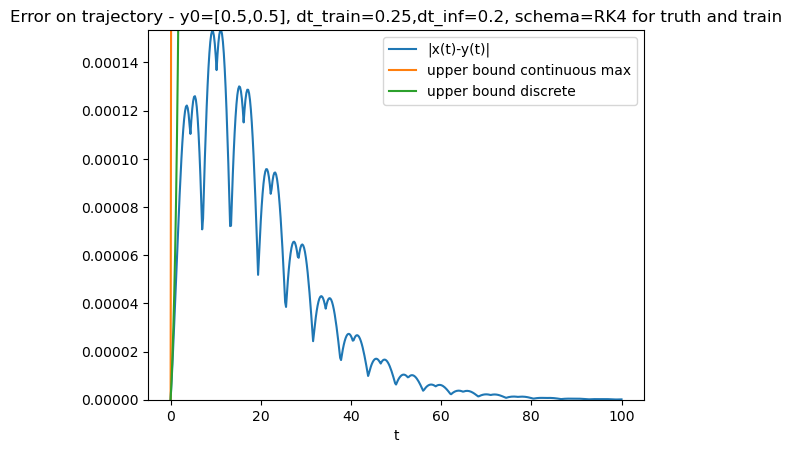

0 0


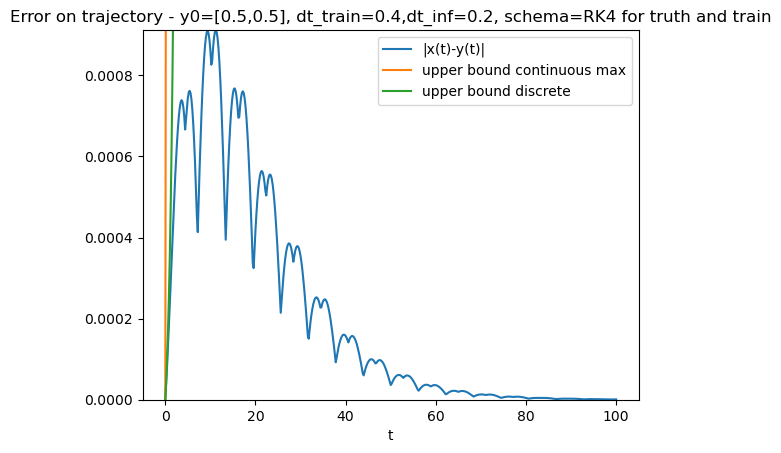

0 0


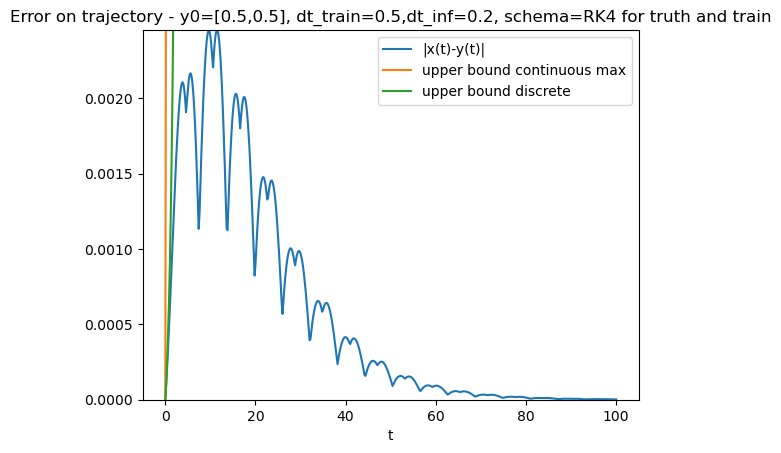

0 0


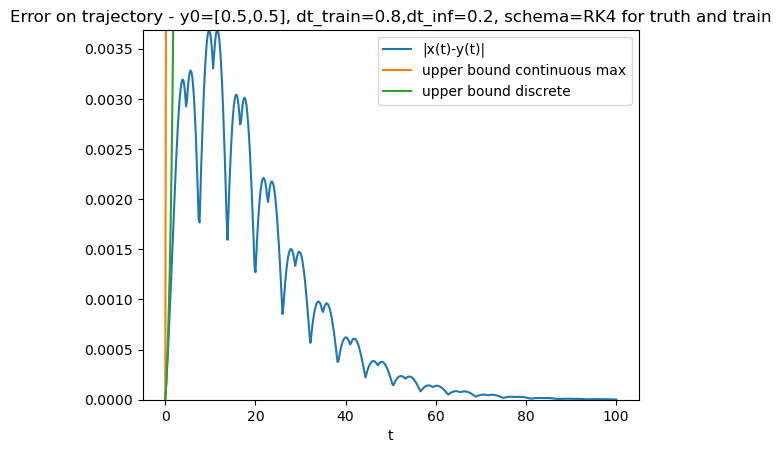

0 0


IndexError: index 5 is out of bounds for axis 0 with size 5

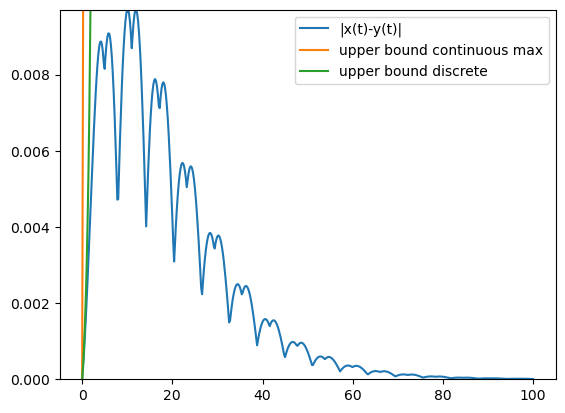

In [315]:
# error on trajectory, with training (ie fitting of theta)
### influence of dt_train (ie theta)
true_param = np.array([(2*np.pi/12)**2, 0.2])
max_errors = []
param_errors = []
y0 = np.array([0.5,0.5])
dt_inf = 0.2 
t1 =100
dt_truth = 0.05
L_errors = []
#y_true, _,_,_ = RK_solver_fixed(F,y0,dt_truth, int((t1-t0)/dt_truth),RK_tableaux["RK4"])
i = 0
for omega, alpha in zip(omegas,alphas):
    def F_theta(y,t): # pour dt=0.1
        q,p = y[0], y[1]
        return jnp.array([p, -omega * jnp.sin(q)-alpha*p])
    # trajectories
    y_true,_,_,_ = RK_solver_fixed(F,y0,dt_inf, int((t1 - t0) / dt_inf),RK_tableaux["RK4"]) #y(T)
    y_pred,_,_,_ = RK_solver_fixed(F_theta,y0,dt_inf, int((t1 - t0) / dt_inf),RK_tableaux["RK4"]) #y(T)
    times = np.arange(t0,t1+dt_inf,dt_inf)
    # param error
    param_error = np.abs(np.array([omega,alpha])-true_param).mean()
    param_errors.append(param_error)
    # Lipschitz constant error 
    L_errors.append(np.abs(np.sqrt(1+ omega**2 + alpha**2)-L))
    # max error on trajectory
    max_errors.append(np.abs(y_true-y_pred).mean(axis=0).max())

    # upper bounds
    epsilon = np.abs(F(y_pred,0)-F_theta(y_pred,0)).mean(axis=0)
    bound_discrete = [0]+[np.sum(np.exp(L*times[t])*(epsilon*np.exp(-L*times)*dt_inf)[:t]) for t in range(1,len(times))] 
    #bound_discrete_max = [0]+[np.exp(L*times[t])*np.sum((m_errors[i]*np.exp(-L*times)*dt_inf)[:t]) for t in range(1,len(times))] 
    bound_continuous_max = upper_bound(times, L, max_errors_[i])
    #bound_continuous = (epsilon/L) *(np.exp(L*times)-1)

    # plots
    plt.plot(times, np.abs(y_true-y_pred).mean(axis=0) , label="|x(t)-y(t)|" )#label=f"param error={round(param_error,4)}")
    plt.plot(times, bound_continuous_max, label="upper bound continuous max")
    #plt.plot(times, bound_continuous, label="upper bound continuous")
    #plt.plot(times, upper_bound(times, L, dt_list[0]**2), label="upper bound continuous dt**2")
    #plt.plot(times, bound_discrete_max, label="upper bound discrete max")
    plt.plot(times, bound_discrete, label="upper bound discrete")  
    print(
          #np.count_nonzero(bound_discrete_max - np.abs(y_true-y_pred).mean(axis=0)<0), 
          np.count_nonzero(bound_discrete - np.abs(y_true-y_pred).mean(axis=0)<0),
          np.count_nonzero(bound_continuous_max - np.abs(y_true-y_pred).mean(axis=0)<0),
          #np.count_nonzero(bound_continuous - np.abs(y_true-y_pred).mean(axis=0)<0),
          )
    i+=1
    plt.ylim(0,max_errors[i-1])
    plt.legend()
    plt.title(f"Error on trajectory - y0=[0.5,0.5], dt_train={dt_list[i]},dt_inf=0.2, schema=RK4 for truth and train")
    plt.xlabel("t")
    plt.show()
    plt.figure()



Investigation of the influence of certain terms below

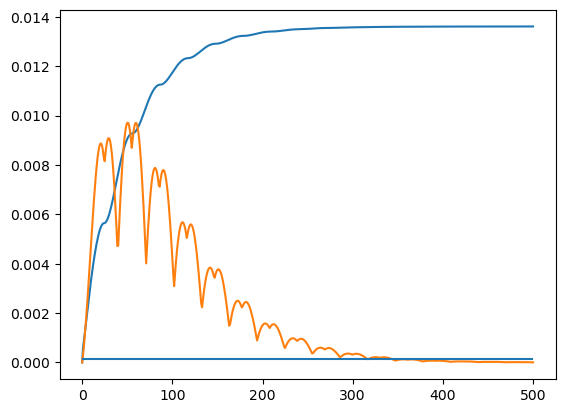

In [316]:
term1 = np.concatenate([np.array([0]), np.cumsum(epsilon*dt_inf)[1:]])
plt.plot(term1)
plt.plot(np.abs(y_true-y_pred).mean(axis=0))
plt.hlines(L*term1[1]*dt_inf, 0, t1/dt_inf)

In [217]:
def term2_f(t):
    exp_list = [np.exp(L*(t-k*dt_inf)) for k in range(int(t/dt_inf))]
    return np.sum(term1[:int(t/dt_inf)]*exp_list)*dt_inf*L

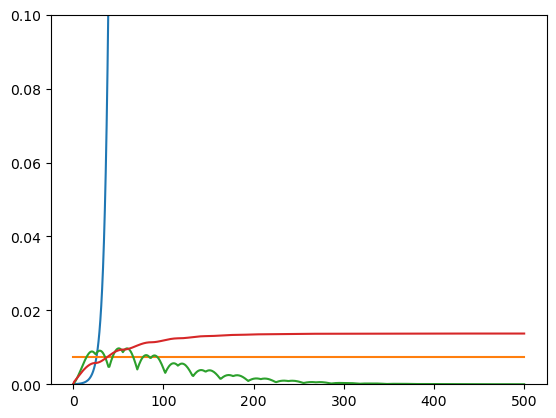

In [231]:
#plt.plot([term2_f(t) for t in times])
plt.plot([term1[1]*np.exp(L*(t-1))*dt_inf for t in times])
plt.plot([term1[-2]*np.exp(L*(t-(t-1)))*dt_inf for t in times])
plt.plot(np.abs(y_true-y_pred).mean(axis=0))
plt.ylim(0,0.1)
plt.plot(term1+ term1[1]*L*dt_inf)


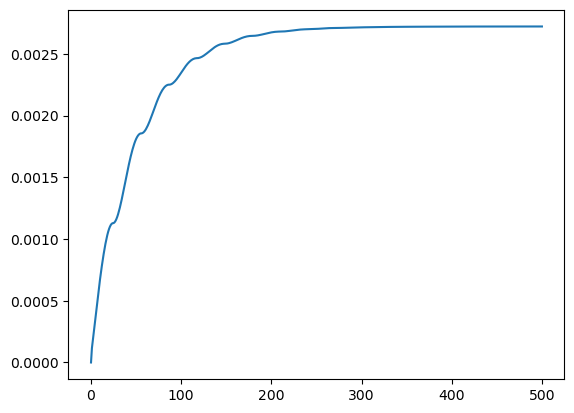

In [215]:
term2 = [L*term1[k]*dt_inf*np.exp(L*(t-k*dt_inf)) for k,t in enumerate(times)]
plt.plot(term2)

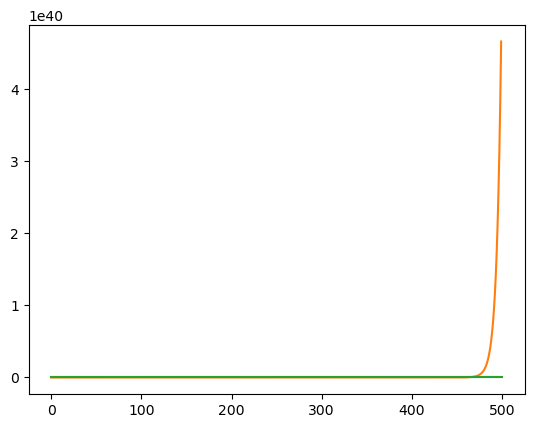

In [205]:
plt.plot([np.exp(L*(-times[k])) for k in range(1,int(100//dt_inf))])
term2 = [0]+ np.array([L*np.sum([term1[k]*np.exp(L*(t-times[k]))*dt_inf for k in range(1,int(t//dt_inf))]) for t in times])[1:]
plt.plot(term2)
plt.plot(np.abs(y_true-y_pred).mean(axis=0))

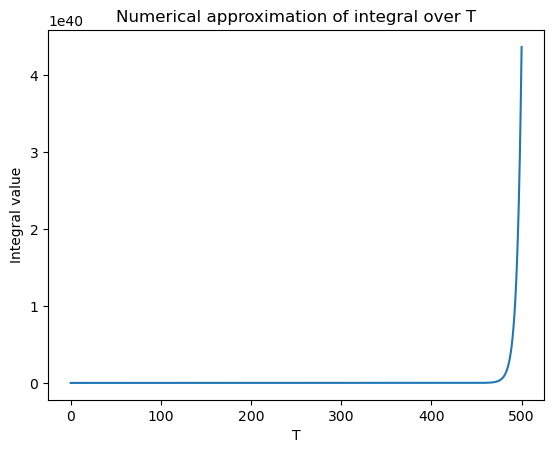

In [170]:
import numpy as np
import matplotlib.pyplot as plt
# Calculate the integral using a discrete sum approximation
plt.plot([
    np.sum(epsilon[:int(T / dt_inf)] * np.exp(L * (T - np.arange(int(T / dt_inf)) * dt_inf)) * dt_inf)
    for T in times
])

plt.xlabel("T")
plt.ylabel("Integral value")
plt.title("Numerical approximation of integral over T")
plt.show()


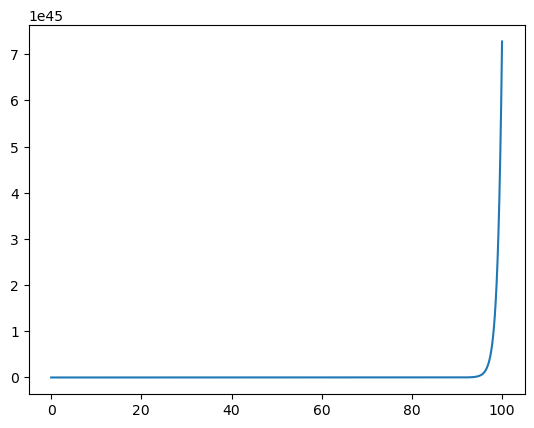

In [162]:
plt.plot(times,np.exp(L*times))

Now we make an error on y0: traj qui fait presque un tour --> initial error is the error that propagates more in our upper bound (then error at t1 with exp(t-1) etc)

0 0 0
0 0 0
0 0 0
0 0 0
0 0 0


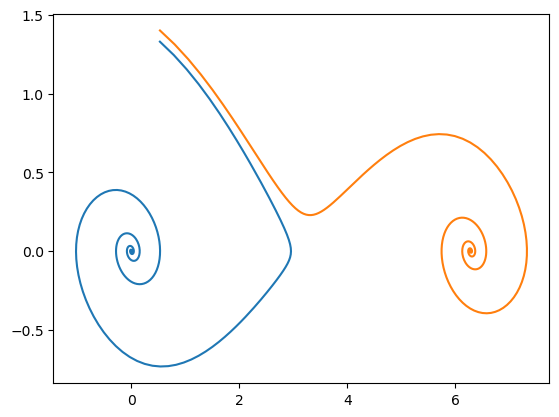

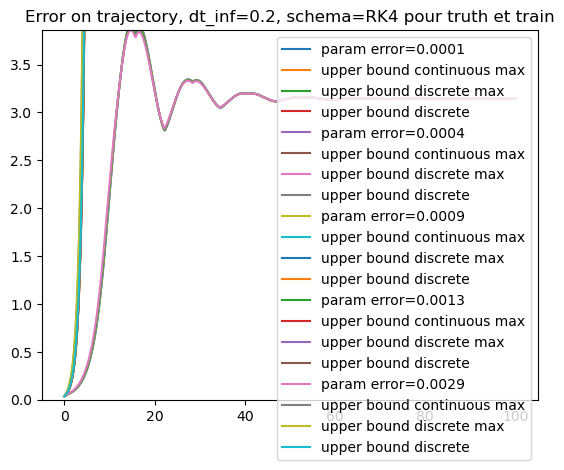

In [268]:
# error on trajectory, with training (ie fitting of theta)
### influence of dt_train (ie theta)
true_param = np.array([(2*np.pi/12)**2, 0.2])
max_errors = []
param_errors = []
y0 = np.array([0.528,1.329]) # traj limite qui fait presque un tour
y0_err = np.array([0.529,1.4]) #np.array([0.528,1.329])#
dt_inf = 0.2 
t1 =100
dt_truth = 0.05
L_errors = []
#y_true, _,_,_ = RK_solver_fixed(F,y0,dt_truth, int((t1-t0)/dt_truth),RK_tableaux["RK4"])
i = 0
for omega, alpha in zip(omegas,alphas):
    def F_theta(y,t): # pour dt=0.1
        q,p = y[0], y[1]
        return jnp.array([p, -omega * jnp.sin(q)-alpha*p])
    # trajectories
    y_true,_,_,_ = RK_solver_fixed(F,y0,dt_inf, int((t1 - t0) / dt_inf),RK_tableaux["RK4"]) #y(T)
    y_pred,_,_,_ = RK_solver_fixed(F_theta,y0_err,dt_inf, int((t1 - t0) / dt_inf),RK_tableaux["RK4"]) #y(T)
    if i == 0:
        plt.plot(y_true[0,:], y_true[1,:], label="truth")
        plt.plot(y_pred[0,:], y_pred[1,:], label="pred")
        plt.figure()
    times = np.arange(t0,t1+dt_inf,dt_inf)
    # param error
    param_error = np.abs(np.array([omega,alpha])-true_param).mean()
    param_errors.append(param_error)
    # Lipschitz constant error 
    L_errors.append(np.abs(np.sqrt(1+ omega**2 + alpha**2)-L))
    # max error on trajectory
    max_errors.append(np.abs(y_true-y_pred).mean(axis=0).max())

    # upper bounds
    epsilon = np.abs(F(y_pred,0)-F_theta(y_pred,0)).mean(axis=0)
    bound_discrete = [np.abs(y0-y0_err).mean()*np.exp(L*times[0])]+[np.abs(y0-y0_err).mean()*np.exp(L*times[t]) + np.sum(np.exp(L*times[t])*(epsilon*np.exp(-L*times)*dt_inf)[:t]) for t in range(1,len(times))] 
    bound_discrete_max = [np.abs(y0-y0_err).mean()*np.exp(L*times[0])]+[np.abs(y0-y0_err).mean()*np.exp(L*times[t]) + np.exp(L*times[t])*np.sum((m_errors[i]*np.exp(-L*times)*dt_inf)[:t]) for t in range(1,len(times))] 
    bound_continuous_max = np.abs(y0-y0_err).mean()*np.exp(L*times)+ upper_bound(times, L, m_errors[i])
    #bound_continuous = (epsilon/L) *(np.exp(L*times)-1)

    # plots
    plt.plot(times, np.abs(y_true-y_pred).mean(axis=0), label=f"param error={round(param_error,4)}")
    plt.plot(times, bound_continuous_max, label="upper bound continuous max")
    #plt.plot(times, bound_continuous, label="upper bound continuous")
    #plt.plot(times, upper_bound(times, L, dt_list[0]**2), label="upper bound continuous dt**2")
    plt.plot(times, bound_discrete_max, label="upper bound discrete max")
    plt.plot(times, bound_discrete, label="upper bound discrete")  
    print(np.count_nonzero(bound_discrete_max - np.abs(y_true-y_pred).mean(axis=0)<0), 
          np.count_nonzero(bound_discrete - np.abs(y_true-y_pred).mean(axis=0)<0),
          np.count_nonzero(bound_continuous_max - np.abs(y_true-y_pred).mean(axis=0)<0),
          #np.count_nonzero(bound_continuous - np.abs(y_true-y_pred).mean(axis=0)<0),
          )
    i+=1
plt.ylim(0,max_errors[i-1])
plt.legend()
plt.title("Error on trajectory, dt_inf=0.2, schema=RK4 pour truth et train")
plt.show()
    #plt.figure()



Conclusion: upper bound is correct but too big in context of online learning + here our system is more than Lipschitz: it is stationary at infinity. 

#### Errors using models directly 
SC: same results as when using F in RK_solver_fixed

In [19]:
dataset_name = 'pendulum'
def load_model(data_path, model_name, exp_name, model_phy_option, model_aug_option, integration_method, dt_factor):
    model_path = os.path.join(data_path, f"{exp_name}/{model_name}")
    print(model_path)
    if dataset_name == 'pendulum':
        if model_phy_option == 'incomplete':
            model_phy = PendulumParamPDE(is_damped=False)
        elif model_phy_option == 'complete':
            model_phy = PendulumParamPDE(is_damped=True)
        elif model_phy_option == 'none':
            model_phy = PendulumParamPDE(is_damped=False) # mock model for eqx compatibility
        elif model_phy_option == 'incomplete_no_Fa':
            model_phy = PendulumParamPDE(is_damped=False)

        with open(model_path, "rb") as f:
            hyperparams = json.loads(f.readline().decode())
            mkey = jax.random.PRNGKey(0)
            model_aug = MLP(key=mkey, state_c=2, hidden=200)
            net = Forecaster(
                model_phy=model_phy,
                model_aug=model_aug,
                is_augmented=model_aug_option,
                is_phy=model_phy_option,
                dt=0.05*dt_factor,
                num_steps=int(20/(0.05*dt_factor)),
                integration_method=integration_method,
            )
            model = eqx.tree_deserialise_leaves(f, net)

    with open(os.path.join(data_path, f'{exp_name}/hyperparameters.json'), 'r') as f:
        min_op = json.load(f)['min_op']
    _lambda = hyperparams['lambda']
    print(min_op)
    return model, _lambda, min_op

In [40]:
pred_list = []
rk2_list = []
rk4_list = []
errors_rk2 = []
errors_rk4 = []
max_errors_rk4 = []
dt_truth = 0.05
y0 = jnp.array([0.5, 0.5])
dataset_name="pendulum"
t1=20
y_truth, _,_,_ = RK_solver_fixed(F,y0,dt_truth, int((t1-t0)/dt_truth),RK_tableaux["RK4"])
for i,dt_factor in enumerate([2,5,8,10,16]):
    exp_name = f'complete_physics_{i+2}_3tfct1zi'
    data_path = 'data/error_scheme'
    model_name = dict_paths[i][-20:-4]+"eqx"
    print(model_name)
    model,_,_ = load_model(data_path, model_name, exp_name, model_phy_option='complete', model_aug_option=False, integration_method="RK2", dt_factor=dt_factor)
    pred = model(jnp.array([0.5, 0.5]))
    def F_theta(y,t):
        q,p = y[0], y[1]
        return jnp.array([p, -omegas[i] * jnp.sin(q)-alphas[i]*p])
    pred_RK2,_,_,_ = RK_solver_fixed(F_theta,jnp.array([0.5, 0.5]),0.05*dt_factor, int(20/(0.05*dt_factor)),RK_tableaux["RK2"])
    pred_RK4, _,_,_ = RK_solver_fixed(F_theta,jnp.array([0.5, 0.5]),0.05*dt_factor, int(20/(0.05*dt_factor)),RK_tableaux["RK4"])
    pred_list.append(pred)
    rk2_list.append(pred_RK2)
    rk4_list.append(pred_RK4)
    errors_rk2.append(np.abs(pred_RK2-pred).mean())
    print(y_truth[:,::dt_factor].shape, pred.shape)
    errors_rk4.append(np.abs(y_truth[:,::dt_factor]-pred).mean())
    max_errors_rk4.append(np.abs(y_truth[:,::dt_factor]-pred).max())

model_1.425e-07.eqx
data/error_scheme/complete_physics_2_3tfct1zi/model_1.425e-07.eqx
l2
(2, 201) (2, 201)
model_5.455e-06.eqx
data/error_scheme/complete_physics_3_3tfct1zi/model_5.455e-06.eqx
l2
(2, 81) (2, 81)
model_3.518e-05.eqx
data/error_scheme/complete_physics_4_3tfct1zi/model_3.518e-05.eqx
l2
(2, 51) (2, 51)
model_8.506e-05.eqx
data/error_scheme/complete_physics_5_3tfct1zi/model_8.506e-05.eqx
l2
(2, 41) (2, 41)
model_5.444e-04.eqx
data/error_scheme/complete_physics_6_3tfct1zi/model_5.444e-04.eqx
l2
(2, 26) (2, 26)


In [321]:
f_mean_errors, m_errors

([0.0006720416, 0.0037782667, 0.008097847, 0.011529856, 0.018788503],
 [0.0006720416, 0.0037782667, 0.008097847, 0.011529856, 0.018788503])

Text(0.5, 1.0, 'Errors on all domain ($\\theta, f_\\theta, L_{\\theta}$)')

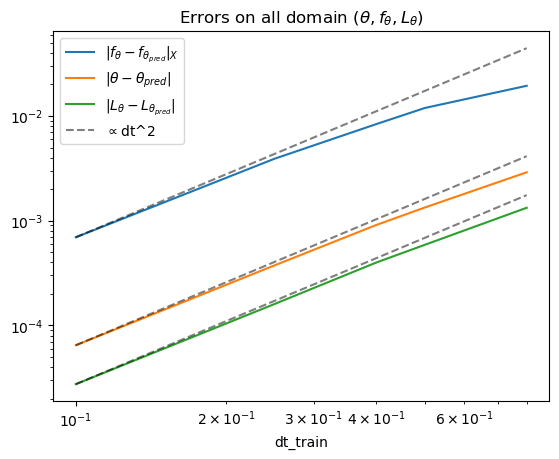

In [45]:
# errors on all domain 
scale = m_errors[0]/(dt_list[0]**2)
plt.plot(dt_list, np.array(m_errors), label=r"$|f_{\theta} - f_{\theta_{pred}}|_X$")
plt.plot(dt_list,  param_errors, label=r"$|\theta - \theta_{pred}|$") 
plt.plot(dt_list, L_errors, label=r"$|L_{\theta}-L_{\theta_{pred}}|$")   
plt.plot(dt_list, scale*(dt_list**2), label=r"$\propto$dt^2", color="black", alpha=0.5, linestyle="--")    
plt.plot(dt_list, param_errors[0]/(dt_list[0]**2)*(dt_list**2), color="black", alpha=0.5, linestyle="--")  
plt.plot(dt_list, L_errors[0]/(dt_list[0]**2)*(dt_list**2), color="black", alpha=0.5, linestyle="--")  
plt.xscale("log")
plt.yscale("log")
plt.xlabel("dt_train")
plt.legend()
plt.title(r"Errors on all domain ($\theta, f_\theta, L_{\theta}$)")

Text(0.5, 1.0, 'Errors trajectory - y0 fixed = [0.5, 0.5], truth=RK4, dt_truth=0.05, t1=20')

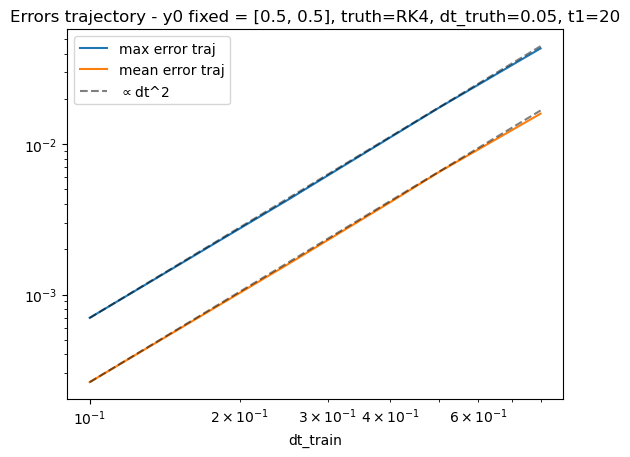

In [46]:
### error y0=[0.5, 0.5]
plt.plot(dt_list, max_errors_rk4, label="max error traj")    
plt.plot(dt_list, max_errors_rk4[0]/(dt_list[0]**2)*(dt_list**2), color="black", alpha=0.5, linestyle="--")
plt.plot(dt_list, errors_rk4, label="mean error traj")
plt.plot(dt_list, errors_rk4[0]/(dt_list[0]**2)*(dt_list**2), color="black", alpha=0.5, label=r"$\propto$dt^2", linestyle="--")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("dt_train")
plt.legend()
plt.title("Errors trajectory - y0 fixed = [0.5, 0.5], truth=RK4, dt_truth=0.05, t1=20")

In [320]:
errors_rk2 

[0.0, 8.062462e-05, 0.0, 0.0, 0.0]

Strange for one dt, using RK_solver_fixed and the model does not give the exact same solution (error of 1e-5)

# ParamODE(omega0)+NN APH: incomplete investigation


In [77]:
_,_,test = init_dataloaders("pendulum", "RK4", "data/lipschitz")

In [81]:
test.dataset.dt

0.5

In [78]:
# Lipschitz
# load model 
import json 
from networks import *
import jax
import equinox as eqx
from datasets import *
import os
from forecasters import *

def load_model(data_path, model_name, exp_name, model_phy_option, model_aug_option, integration_method):
    model_path = os.path.join(data_path, f"{exp_name}/{model_name}")
    print(model_path)
    if dataset_name == 'pendulum':
        if model_phy_option == 'incomplete':
            model_phy = PendulumParamPDE(is_damped=False)
        elif model_phy_option == 'complete':
            model_phy = PendulumParamPDE(is_damped=True)
        elif model_phy_option == 'true':
            model_phy = PendulumParamPDE(is_damped=True, params=test.dataset.params)
        elif model_phy_option == 'none':
            model_phy = PendulumParamPDE(is_damped=False) # mock model for eqx compatibility
        elif model_phy_option == 'incomplete_no_Fa':
            model_phy = PendulumParamPDE(is_damped=False)

        with open(model_path, "rb") as f:
            hyperparams = json.loads(f.readline().decode())
            mkey = jax.random.PRNGKey(0)
            model_aug = MLP(key=mkey, state_c=2, hidden=200)
            net = Forecaster(
                model_phy=model_phy,
                model_aug=model_aug,
                is_augmented=model_aug_option,
                is_phy=model_phy_option,
                dt=test.dataset.dt,
                num_steps=test.dataset.num_steps,
                integration_method=integration_method,
            )
            model = eqx.tree_deserialise_leaves(f, net)

    with open(os.path.join(data_path, f'{exp_name}/hyperparameters.json'), 'r') as f:
        min_op = json.load(f)['min_op']
    _lambda = hyperparams['lambda']
    print(min_op)
    return model, _lambda, min_op

exp_name = 'incomplete_aug_20_srefavep'
model_name = 'model_4.321e-04.eqx'
data_path = 'data/lipschitz'
model_phy_option = 'incomplete'
model_aug_option = True
dataset_name = 'pendulum'
integration_method = 'RK4'
model_sc2, _lambda, min_op = load_model(data_path, model_name, exp_name, model_phy_option, model_aug_option, integration_method)
F_sc2 = model_sc2.derivative_estimator

data/lipschitz/incomplete_aug_20_srefavep/model_4.321e-04.eqx
l2


In [83]:
model_sc2.model_phy.omega0_square, model_sc2.model_phy.alpha

(Array(0.26080474, dtype=float32), 0.0)

In [102]:
def F_inc(y,t):
    q,p = y[0], y[1]
    return jnp.array([p, -model_sc2.model_phy.omega0_square * jnp.sin(q)-model_sc2.model_phy.alpha*p])

In [103]:
def F_lin(y,t):
    q,p = y[0], y[1]
    return jnp.array([p, -true_param[0] * q- true_param[1]*p])

In [127]:
def F(y,t):
    q,p = y[0], y[1]
    return jnp.array([p, -(2*np.pi/12)**2 * jnp.sin(q)-0.2*p])

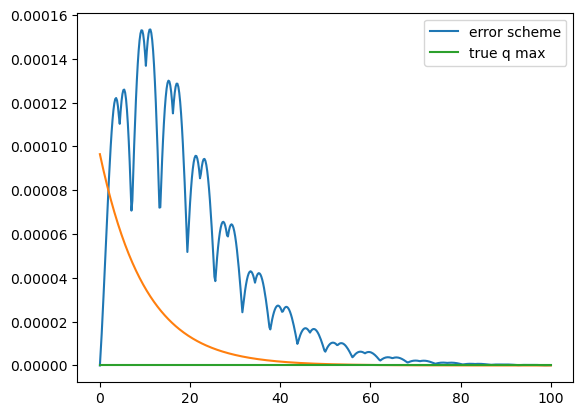

In [141]:
true_param = np.array([(2*np.pi/12)**2, 0.2])
y0 = np.array([0.5,0.5])
dt_inf = 0.2 
t1 =100
def F_theta(y,t):
    q,p = y[0], y[1]
    return jnp.array([p, -omegas[0] * jnp.sin(q)-alphas[0]*p])
omega_p = np.sqrt(4*true_param[0]**2 - true_param[1]**2)
y_true,_,_,_ = RK_solver_fixed(F,y0,dt_inf, int((t1 - t0) / dt_inf),RK_tableaux["RK4"]) #y(T)
y_inc, _,_,_ = RK_solver_fixed(F_inc,y0,dt_inf, int((t1 - t0) / dt_inf),RK_tableaux["RK4"]) #y(T)
y_lin,_,_,_= RK_solver_fixed(F_lin,y0,dt_inf, int((t1 - t0) / dt_inf),RK_tableaux["RK4"]) #y(T)
y_pred,_,_,_ = RK_solver_fixed(F_sc2,y0,dt_inf, int((t1 - t0) / dt_inf),RK_tableaux["RK4"]) #y(T)
y_scheme, _,_,_ = RK_solver_fixed(F_theta,y0,dt_inf, int((t1 - t0) / dt_inf),RK_tableaux["RK4"]) #y(T)
times = np.arange(t0,t1+dt_inf,dt_inf)
#plt.plot(times, np.abs(y_true-y_pred).mean(axis=0), label="error pred")
plt.plot(times, np.abs(y_true-y_scheme).mean(axis=0), label="error scheme")
#plt.hlines(true_param[0]-model_sc2.model_phy.omega0_square, 0, t1, label="error omega")
#plt.plot(times, y_true[0,:], label="true q")
#plt.plot(times, y_pred[0,:], label="pred q")
#plt.plot(times, y_pred[1,:], label="pred p")
#plt.plot(times, y_true[1,:], label="true p")
#plt.plot(times, y_lin[0,:], label="lin q")
L_epsilon = np.sqrt((0.2-alphas[0])**2 + (omegas[0]-true_param[0])**2)
plt.plot(times, np.exp(-(0.2)/2*times)*L_epsilon)
plt.plot(times, np.exp(-(0.2-alphas[0])/2*times)* (y_true[0,0]-y_scheme[0,0] + (y_true[1,0]-y_scheme[1,0]+ (0.2-alphas[0])*(y_true[0,0]-y_scheme[0,0])/2)/np.sqrt(4*omegas[0]**2-alphas[0]**2)), label="true q max")
#plt.plot(times,np.exp(-0.2/2*times)*(y_lin[0,0] + (y_lin[1,0]+ 0.2*y_lin[0,0]/2)/omega_p), label="lin q max")
#plt.plot(times, np.exp(-0.2/2*times)* (y_true[0,0] + (y_true[1,0]+ 0.2*y_true[0,0]/2)/omega_p), label="true q max")
plt.legend()
#plt.plot(times, np.abs(y_true-y_inc).mean(axis=0), label="error inc")
plt.show()

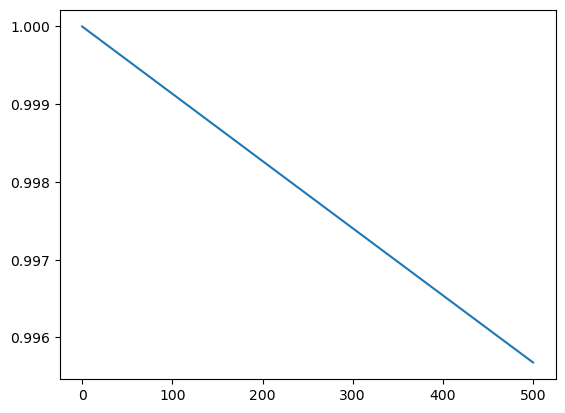

In [133]:
plt.plot(np.exp(-(0.2-alphas[0])/2*times))

In [120]:
(np.exp(-0.2/2*times)* (y_true[0,0] + (y_true[1,0]+ 0.2*y_true[0,0]/2)/omega_p) - y_true[0,:]).min()

Array(1.8794231e-05, dtype=float32)

In [97]:
0.2**2 - 4* (2*np.pi/12)**4 

-0.26064534269753825

# Deprecated: Influence of dt at inference and $y_0$: tests à la main

Notre f dépend de l'ordre du schéma, du dt choisi (qui détermine le théta) et du y0. On fixe le schéma RK2, et on a entrainé nos modèles en RK2 avec différents dt aboutissant à différents thétas. On peut ensuite l'appliquer à différents y0. On utilise un dt_inf pour l'inférence. 

In [371]:
dt_list = np.array([2,5,8,10,16])*0.05
omegas, alphas # list of learned parameters

([0.27411317825317383,
  0.27389439940452576,
  0.2733769118785858,
  0.2729674279689789,
  0.2707677185535431],
 [0.1999133825302124,
  0.1995130479335785,
  0.1989569514989853,
  0.1985151171684265,
  0.19758717715740204])

In [372]:
def F(y,t):
    q,p = y[0], y[1]
    return jnp.array([p, -(2*np.pi/12)**2 * jnp.sin(q)-0.2*p])

def F_theta(y,t): # dt=0.1
    q,p = y[0], y[1]
    return jnp.array([p, -omegas[0] * jnp.sin(q)-alphas[0]*p])

(34,) (35,)
(51,) (51,)
(101,) (101,)
(167,) (168,)
(251,) (251,)
(501,) (501,)
(1001,) (1001,)
(100001,) (100001,)


(0.0, 0.04)

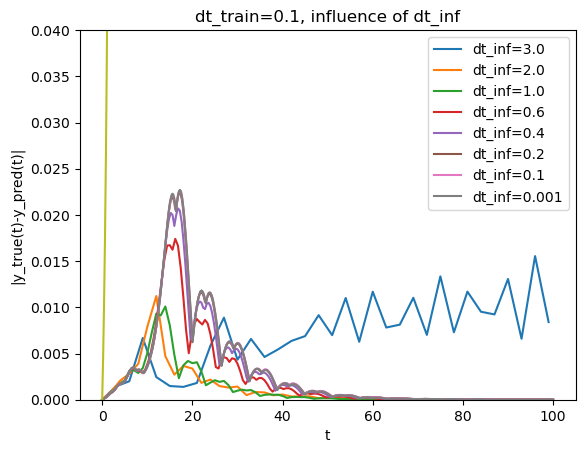

In [373]:
### impact of dt_inf
t1 = 100
y0 = np.array([2.,6.])
fig, ax = plt.subplots(1,1)
error_max_list = []
for dt_inf in [3., 2.,1.,0.6, 0.4,0.2,0.1, 0.001]:
    y_true, _,_,_= RK_solver_fixed(F,y0,dt_inf, int((t1 - t0) / dt_inf),RK_tableaux["RK2"]) 
    y_pred,_,_,_ = RK_solver_fixed(F_theta,y0,dt_inf, int((t1 - t0) / dt_inf),RK_tableaux["RK2"]) 
    error = np.abs(y_true-y_pred).mean(axis=0)
    error_max_list.append(error.max())
    times = np.arange(t0,t1+dt_inf,dt_inf)
    print(error.shape, times.shape)
    ax.plot(times[:len(error)], error, label=f"dt_inf={dt_inf}")
    #ax[1].plot(y_true[0,:], y_true[1,:], label=f"dt_inf={dt_inf}")
    #ax[1].plot(y_pred[0,:], y_pred[1,:], label=f"dt_inf={dt_inf}")

# dt_inf2 = 0.1
# y_true2, _,_,_= RK_solver_fixed(F,y0,dt_inf2, int((t1 - t0) / dt_inf2),RK_tableaux["RK2"])
# y_pred2,_,_,_ = RK_solver_fixed(F_theta,y0,dt_inf2, int((t1 - t0) / dt_inf2),RK_tableaux["RK2"])
# error2 = np.abs(y_true2-y_pred2).mean(axis=0)
# times2 = np.arange(t0,t1+dt_inf2,dt_inf2)
# plt.plot(times, error, label=f"dt_inf={dt_inf}")
# plt.plot(times2, error2, label=f"dt_inf={dt_inf2}")
plt.legend()
epsilon_max = 2*(dt_train**2)
plt.plot(times, upper_bound1(times,L,epsilon_max), label="upper_bound1")
plt.title("dt_train=0.1, influence of dt_inf")
plt.xlabel("t")
plt.ylabel("|y_true(t)-y_pred(t)|")
plt.ylim(0,0.04)

when dt<1, augmenting it improves error trajectory until dt=1. If dt>1 increases, the loss increases. When dt becomes smaller than the one used for training, the error resembles the dt_train one. 

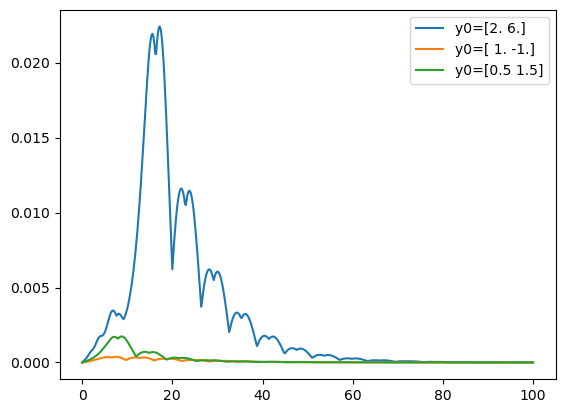

In [296]:
### impact of y0
dt_inf = 0.2
dt_train = 0.1
for y0 in [[2.,6.],[1.,-1.],[0.5,1.5]]:
    y0 = np.array(y0)
    y_true, _,_,_= RK_solver_fixed(F,y0,dt_inf, int((t1 - t0) / dt_inf),RK_tableaux["RK2"]) 
    y_pred,_,_,_ = RK_solver_fixed(F_theta,y0,dt_inf, int((t1 - t0) / dt_inf),RK_tableaux["RK2"]) 
    error = np.abs(y_true-y_pred).mean(axis=0)
    times = np.arange(t0,t1+dt_inf,dt_inf)
    plt.plot(times, error, label=f"y0={y0}")
#plt.hlines(dt_inf**2,0,t1,label="dt_inf^2")
#plt.hlines(dt_train**2,0,t1,label="dt_train^2", color='red')
#plt.hlines(param_errors[0]**2,0,t1,label="param_error", color='green')
#plt.plot(times, param_errors[0]*times, label="param_error")
plt.plot(times, upper_bound1(times,L,epsilon_max), label="upper_bound1")
plt.legend()

0.0507814

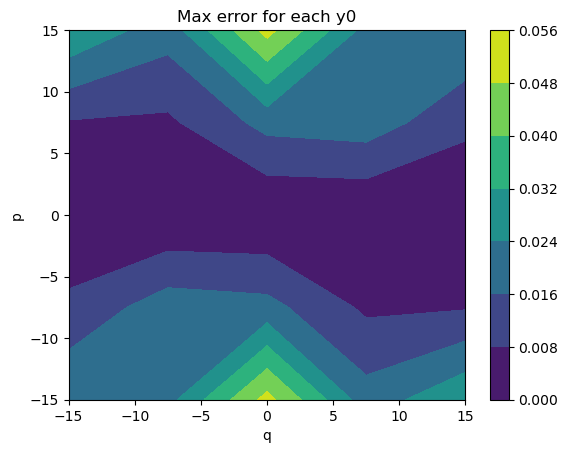

In [299]:
q = np.linspace(-15, 15, 5)
p = np.linspace(-15, 15, 5)
Q, P = np.meshgrid(q, p)
dt_inf=0.5
# get error max for each y0 in Q,P
errors = []
for y0 in zip(Q.ravel(), P.ravel()):
    y0 = np.array(y0)
    y_true, _,_,_= RK_solver_fixed(F,y0,dt_inf, int((t1 - t0) / dt_inf),RK_tableaux["RK2"]) 
    y_pred,_,_,_ = RK_solver_fixed(F_theta,y0,dt_inf, int((t1 - t0) / dt_inf),RK_tableaux["RK2"]) 
    error = np.abs(y_true-y_pred).mean(axis=0).max()
    errors.append(error)
errors = np.array(errors).reshape(Q.shape)
plt.contourf(Q,P,errors)
plt.colorbar()
plt.xlabel("q")
plt.ylabel("p")
plt.title("Max error for each y0")
errors.max()


In [369]:
L = np.sqrt(1 + true_alpha**2 + true_omega**4)
L_theta = np.sqrt(1 + alphas[0]**2 + omegas[0]**2)
L, L_theta

(1.0560119959898109, 1.0559845619168526)

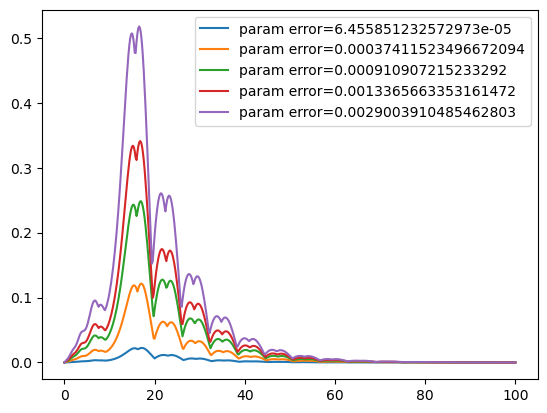

In [318]:
### influence of dt_train (ie theta)
max_errors = []
param_errors = []
y0 = np.array([2.,6.])
dt_inf = 0.2 
for omega, alpha in zip(omegas,alphas):
    def F_theta(y,t): # pour dt=0.1
        q,p = y[0], y[1]
        return jnp.array([p, -omega * jnp.sin(q)-alpha*p])
    y_true,_,_,_ = RK_solver_fixed(F,y0,dt_inf, int((t1 - t0) / dt_inf),RK_tableaux["RK2"]) #y(T)
    y_pred,_,_,_ = RK_solver_fixed(F_theta,y0,dt_inf, int((t1 - t0) / dt_inf),RK_tableaux["RK2"]) #y(T)
    times = np.arange(t0,t1+dt_inf,dt_inf)
    param_error = np.abs(np.array([omega,alpha])-true_param).mean()
    param_errors.append(param_error)
    plt.plot(times, np.abs(y_true-y_pred).mean(axis=0), label=f"param error={param_error}")
    max_errors.append( np.abs(y_true-y_pred).mean(axis=0).max())
plt.legend()
plt.show()

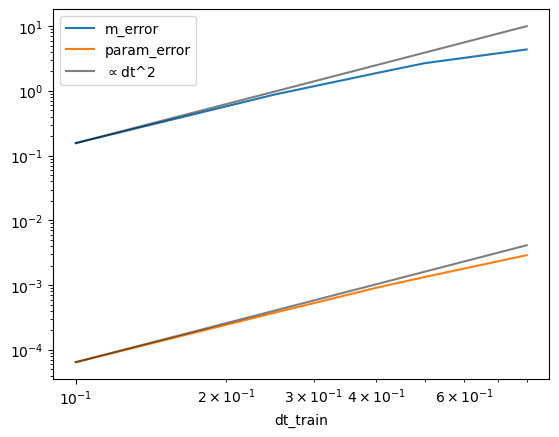

In [403]:
### influence of dt_train (ie theta)
m_errors = []
dt_inf = 0.2 
q = np.linspace(-15, 15, 15)
p = np.linspace(-15, 15, 15)
Q, P = np.meshgrid(q, p)
for omega, alpha in zip(omegas,alphas):
    def F_error(y,t): # pour dt=0.1
        q,p = y[0], y[1]
        pred = jnp.array([p, -omega * jnp.sin(q)-alpha*p])
        true = jnp.array([p, -(2*np.pi/12)**2 * jnp.sin(q)-0.2*p])
        return np.linalg.norm(pred-true)
    
    # integrate over all y0
    m_error = 0
    for y0 in zip(Q.ravel(), P.ravel()):
        y0 = np.array(y0)
        m_error += F_error(y0,0)
    m_errors.append(m_error)

scale = m_errors[0]/(dt_list[0]**2)
plt.plot(dt_list, np.array(m_errors), label="m_error")
plt.plot(dt_list,  param_errors, label="param_error")    
plt.plot(dt_list, scale*(dt_list**2), label=r"$\propto$dt^2", color="black", alpha=0.5)    
plt.plot(dt_list, param_errors[0]/(dt_list[0]**2)*(dt_list**2), color="black", alpha=0.5)    
plt.xscale("log")
plt.yscale("log")
plt.xlabel("dt_train")
plt.legend()